<a href="https://colab.research.google.com/github/LoshithaAI/ML-Assignment/blob/thuiyadura-lr-ms26923956/notebooks/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b thuiyadura-lr-ms26923956 https://github.com/LoshithaAI/ML-Assignment.git

Cloning into 'ML-Assignment'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 29 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 110.72 KiB | 1003.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
!ls ML-Assignment

data  notebooks  README.md


# Predicting Student Dropout and Academic Success — Logistic Regression
**Fundamentals of Machine Learning – Programming Assignment**

| | |
|---|---|
| **Member** | `Thuiyadura L.R` (`MS26923956`) |
| **Algorithm** | Logistic Regression (multinomial) |
| **Teammate's algorithm** | Random Forest (`random_forest.ipynb`) |
| **Learning type** | Supervised learning – multi-class classification |

**Notebook map (matches the marking rubric)**

| Section | Rubric item |
|---|---|
| 1. Setup | – |
| 2. Dataset description | #1 Dataset selection, #2 Description |
| 3. Data preprocessing | #3 Preprocessing |
| 4. Algorithm background and justification | #4 Application of algorithm |
| 5. Model implementation (baseline + tuning) | #4, #5 Implementation |
| 6. Results on the test set | #6 Results |
| 7. Improvement experiments, critical analysis, future work | #7 Discussion |
| 8. Individual contribution and viva notes | #8, #9 |

In [3]:
# --- Libraries -------------------------------------------------------------
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [4]:
# --- Load the dataset ------------------------------------------------------
import os
GITHUB_RAW_URL = "https://raw.githubusercontent.com/LoshithaAI/ML-Assignment/thuiyadura-lr-ms26923956/data/data.csv"

for path in ["data.csv", "data/data.csv", "../data/data.csv"]:
    if os.path.exists(path):
        DATA_PATH = path
        break
else:
    DATA_PATH = GITHUB_RAW_URL

df = pd.read_csv(DATA_PATH, sep=";")
df.columns = df.columns.str.strip()
print("Loaded from:", DATA_PATH)
print("Shape:", df.shape)

Loaded from: https://raw.githubusercontent.com/LoshithaAI/ML-Assignment/thuiyadura-lr-ms26923956/data/data.csv
Shape: (4424, 37)


## 2. Dataset selection and description

**Dataset:** *Predict Students' Dropout and Academic Success*
**Source (UCI Machine Learning Repository):** https://archive.ics.uci.edu/dataset/697
**License:** CC BY 4.0 &nbsp;|&nbsp; **Citation:** `Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict Students' Dropout and Academic Success [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89.`

> Add blockquote



**Context.** The data comes from a Portuguese higher-education institution and combines information known at enrollment
(demographics, socioeconomic background, academic path), the student's academic performance at the end of the 1st and 2nd
semesters, and national macroeconomic indicators. It was created to identify students at risk of dropping out so that
the institution can support them early. Each row is one student enrolled in an undergraduate programme
(e.g. agronomy, design, education, nursing, journalism, management, social service, technologies).

**Why it is a suitable dataset**
- Real-world, published online, and hosted on UCI (a credible public repository).
- Not a standard tutorial dataset (unlike Iris/Titanic), and reasonably complex: **4,424 rows, 36 features, 3 classes**.
- Mixed feature types (categorical codes, binary flags, continuous grades) and **imbalanced classes**, which makes the evaluation interesting.

**Target variable:** `Target` – `Dropout`, `Enrolled` or `Graduate` (status at the end of the normal course duration).

**Attributes (36 features + target)**

| Group | Attributes | Type |
|---|---|---|
| Demographic | Marital status, Nacionality, Gender, Age at enrollment, International, Displaced | Categorical code / binary / numeric |
| Application | Application mode, Application order, Course, Daytime/evening attendance | Categorical code / ordinal / binary |
| Previous education | Previous qualification, Previous qualification (grade), Admission grade | Categorical code / numeric |
| Family background | Mother's qualification, Father's qualification, Mother's occupation, Father's occupation | Categorical code |
| Financial / special | Educational special needs, Debtor, Tuition fees up to date, Scholarship holder | Binary |
| 1st-semester performance | Curricular units 1st sem (credited, enrolled, evaluations, approved, grade, without evaluations) | Numeric |
| 2nd-semester performance | Curricular units 2nd sem (credited, enrolled, evaluations, approved, grade, without evaluations) | Numeric |
| Macroeconomic | Unemployment rate, Inflation rate, GDP | Numeric |

> The code-valued columns (Marital status, Application mode, Course, Previous qualification, Nacionality, parents'
> qualification and occupation) are **integer labels for categories, not quantities**. The lookup tables are on the UCI page.

In [6]:
display(df.head())
print("Rows, columns:", df.shape)
print("Features:", df.shape[1] - 1, "| Target: Target")

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Rows, columns: (4424, 37)
Features: 36 | Target: Target


          count  percent
Target                  
Graduate   2209     49.9
Dropout    1421     32.1
Enrolled    794     17.9


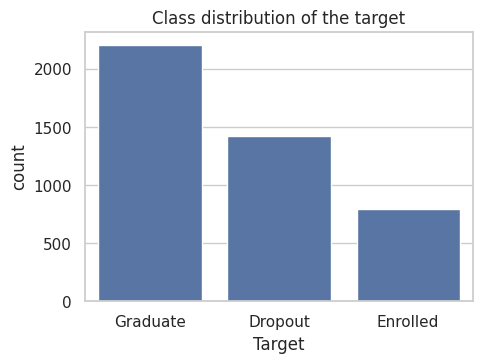

In [7]:
# Class distribution of the target
counts = df["Target"].value_counts()
print(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)}))

plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x="Target", order=counts.index)
plt.title("Class distribution of the target")
plt.show()

In [8]:
# Summary statistics of the continuous attributes
cat_cols = ["Marital status", "Application mode", "Course", "Previous qualification", "Nacionality",
            "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
binary_cols = [c for c in df.columns if c not in cat_cols + ["Target"] and df[c].nunique() <= 2]
num_cols = [c for c in df.columns if c not in cat_cols + binary_cols + ["Target", "Application order"]]

print("Categorical-code columns :", len(cat_cols))
print("Binary (0/1) columns     :", len(binary_cols))
print("Continuous columns       :", len(num_cols))
df[num_cols].describe().T.round(2)

Categorical-code columns : 9
Binary (0/1) columns     : 8
Continuous columns       : 18


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Curricular units 1st sem (credited),4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 1st sem (without evaluations),4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00
Curricular units 2nd sem (credited),4424.0,0.54,1.92,0.00,0.00,0.00,0.00,19.00


## 3. Data Preprocessing

The data preprocessing stage prepares the dataset for the Logistic Regression model. The following steps are performed:

### 3.1 Data Cleansing
- Check for missing values.
- Check for duplicate records.
- Verify data types and column names.
- Identify and handle any invalid or inconsistent values.

### 3.2 Outlier Analysis
- Analyze numerical features for potential outliers.
- Use statistical methods and visualizations to identify unusual observations.
- Assess whether identified outliers require treatment.

### 3.3 Exploratory Data Analysis
- Analyze the distribution of the target variable.
- Examine relationships between selected features and the target.
- Use appropriate visualizations to understand patterns and class distributions.

### 3.4 Encoding
- Identify categorical features.
- Convert categorical variables into numerical representations where required.
- Ensure that all features are in a suitable format for Logistic Regression.

### 3.5 Train/Test Split
- Separate the input features (`X`) from the target variable (`y`).
- Split the dataset into training and testing sets.
- Use stratification to maintain the target class distribution in both sets.

### 3.6 Feature Scaling
- Standardize numerical features where appropriate.
- Fit the scaler using only the training data to prevent data leakage.
- Apply the same transformation to the test data.

### 3.7 Dimensionality Reduction Analysis
- Analyze whether dimensionality reduction is necessary.
- Consider Principal Component Analysis (PCA) if appropriate.
- Compare the usefulness of dimensionality reduction before deciding whether to include it in the final Logistic Regression model.

### 3.1 Data cleansing

**Finding:** no missing values and no duplicates, so no imputation or row removal is needed. The only cleaning needed was
the semicolon delimiter and removing whitespace from the column names (done in Section 1).

In [9]:
print("Missing values (total):", int(df.isna().sum().sum()))
print("Duplicate rows        :", int(df.duplicated().sum()))
print("Non-numeric columns   :", list(df.select_dtypes(exclude="number").columns))

Missing values (total): 0
Duplicate rows        : 0
Non-numeric columns   : ['Target']


### 3.2 Outlier analysis

,feature,n_outliers,percent
13,Curricular units 2nd sem (grade),877,19.8
7,Curricular units 1st sem (grade),726,16.4
3,Curricular units 1st sem (credited),577,13.0
9,Curricular units 2nd sem (credited),530,12.0
2,Age at enrollment,441,10.0
4,Curricular units 1st sem (enrolled),424,9.6
10,Curricular units 2nd sem (enrolled),369,8.3
8,Curricular units 1st sem (without evaluations),294,6.6


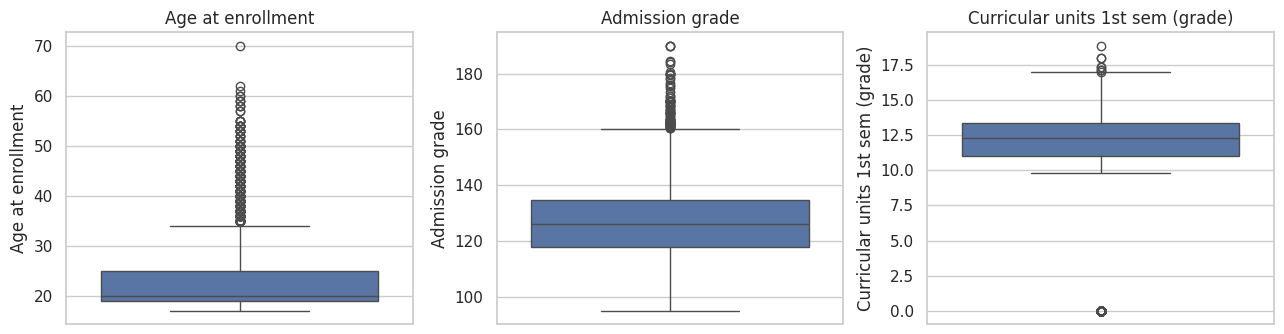

In [10]:
# IQR rule: values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] are flagged as potential outliers
rows = []
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum())
    rows.append((c, n_out, round(n_out / len(df) * 100, 1)))
outliers = pd.DataFrame(rows, columns=["feature", "n_outliers", "percent"]).sort_values("n_outliers", ascending=False)
display(outliers.head(8))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c in zip(axes, ["Age at enrollment", "Admission grade", "Curricular units 1st sem (grade)"]):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Decision:** the flagged values are genuine observations, not data-entry errors, so they are kept. Two groups explain most of the flags. First, mature students (age up to 70; 248 students are 40 or older, and about half of them dropped out). Second, students with a grade of 0 in the curricular-unit grade columns (718 in the 1st semester and 870 in the 2nd): every one of them has 0 approved units, so the 0 means "no grade earned" rather than a true score of zero. These students are strongly associated with dropout (about 79% and 84% respectively), so removing them would delete exactly the at-risk students the model needs to identify. Standardisation in 3.6 puts features on a common scale but does not remove outliers. Their influence on Logistic Regression is limited by L2 regularisation (the C parameter).

### 3.3 Exploratory analysis

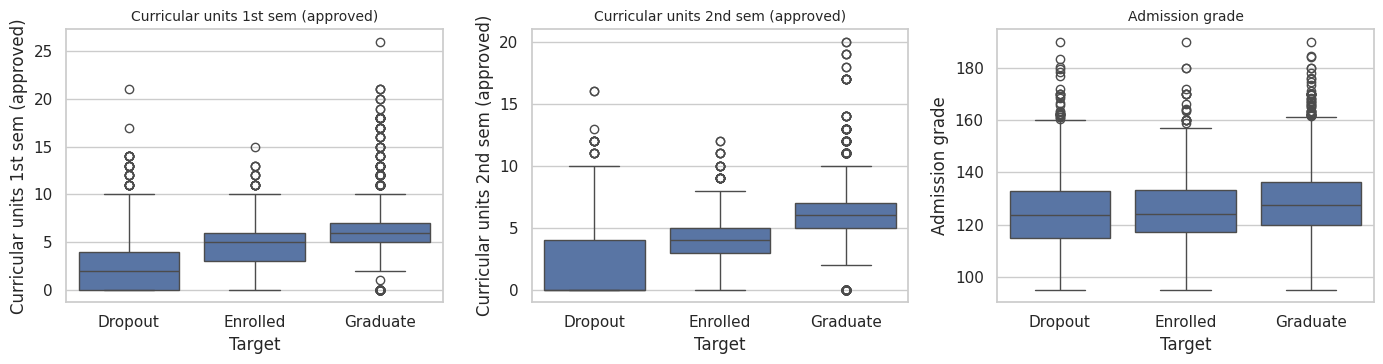

In [11]:
# How do academic-performance features differ by outcome?
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, c in zip(axes, ["Curricular units 1st sem (approved)",
                        "Curricular units 2nd sem (approved)",
                        "Admission grade"]):
    sns.boxplot(data=df, x="Target", y=c, order=["Dropout", "Enrolled", "Graduate"], ax=ax)
    ax.set_title(c, fontsize=10)
plt.tight_layout()
plt.show()

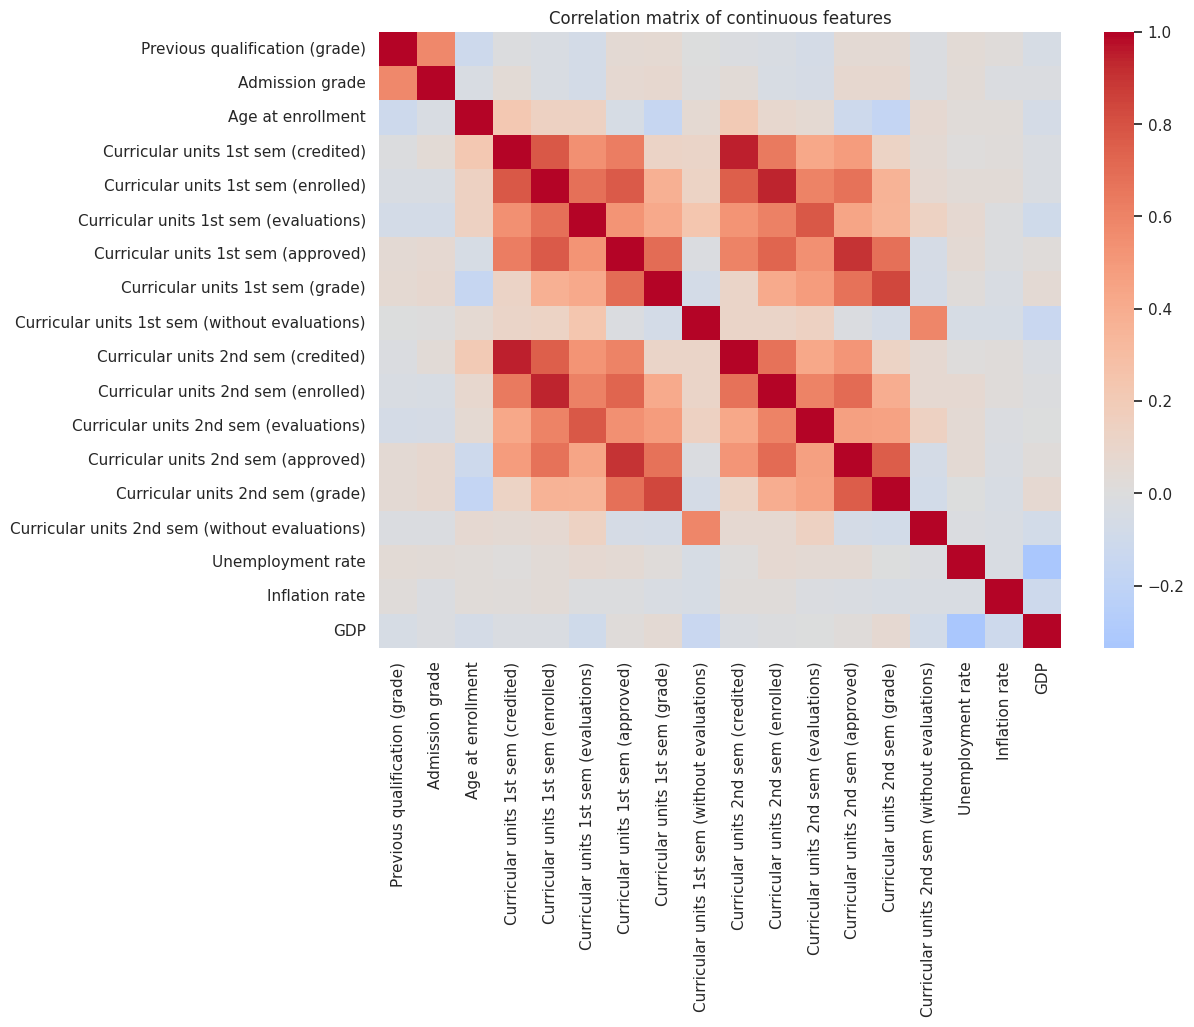

In [12]:
# Correlation between the continuous attributes
plt.figure(figsize=(11, 8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix of continuous features")
plt.show()

**Observations**: The number of approved curricular units differs clearly by outcome: the median rises from Dropout (2 in the 1st semester, 0 in the 2nd) through Enrolled (5 and 4) to Graduate (6 and 6). The groups still overlap, particularly Dropout and Enrolled, and "Enrolled" sits between the other two, which suggests it will be the hardest class to predict. In contrast, admission grade differs very little between the groups (medians of about 124, 124 and 127), so entry grades are a weak predictor on their own. The correlation matrix shows strong correlations between the curricular-unit features, both within a semester (e.g. enrolled vs. approved, r = 0.77) and between semesters (credited and enrolled r = 0.94, approved r = 0.90). This multicollinearity is one reason to use regularisation in Logistic Regression. The macroeconomic variables and age are only weakly correlated with the academic features.

### 3.4 Encoding categorical features

The nine code-valued columns are **labels**, not quantities. A linear model would wrongly treat `Course = 9254` as
"larger" than `Course = 171`, so these are **one-hot encoded**. Binary 0/1 flags and continuous columns need no encoding.
`drop_first=True` removes one dummy per feature to avoid perfect collinearity.

In [13]:
X = pd.get_dummies(df.drop(columns="Target"), columns=cat_cols, drop_first=True)
y = df["Target"]
print("Features before encoding:", df.shape[1] - 1)
print("Features after encoding :", X.shape[1])

Features before encoding: 36
Features after encoding : 238


### 3.5 Train/test split

In [14]:
# 80/20 split, STRATIFIED so each part keeps the same class proportions.
# Use exactly the same settings as your teammate so the models are compared fairly.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class %:", (y_train.value_counts(normalize=True) * 100).round(1).to_dict())
print("Test  class %:", (y_test.value_counts(normalize=True) * 100).round(1).to_dict())

Train: (3539, 238) | Test: (885, 238)
Train class %: {'Graduate': 49.9, 'Dropout': 32.1, 'Enrolled': 17.9}
Test  class %: {'Graduate': 49.9, 'Dropout': 32.1, 'Enrolled': 18.0}


### 3.6 Feature scaling

Logistic Regression is trained by gradient-based optimisation with a regularisation penalty, so features on very different scales
(e.g. grades 0–200 vs. 0/1 flags) can distort the solution. The continuous columns are **standardised** (mean 0, std 1).

To avoid **data leakage**, scaling is placed **inside a `Pipeline`**: the scaler is fitted only on the training part of each
cross-validation fold, never on validation or test data.

In [15]:
def build_pipeline(scale_cols, C=1.0, class_weight=None, penalty="l2", solver="lbfgs", max_iter=5000):
    """Scaling (on continuous columns only) + Logistic Regression in one pipeline."""
    scaler = ColumnTransformer([("scale", StandardScaler(), scale_cols)], remainder="passthrough")
    clf = LogisticRegression(C=C, class_weight=class_weight, penalty=penalty,
                             solver=solver, max_iter=max_iter, random_state=RANDOM_STATE)
    return Pipeline([("prep", scaler), ("clf", clf)])

print("Continuous columns that will be scaled:", len(num_cols))

Continuous columns that will be scaled: 18


### 3.7 Dimensionality reduction analysis (PCA)

238 features -> 48 components keep 95% of the variance


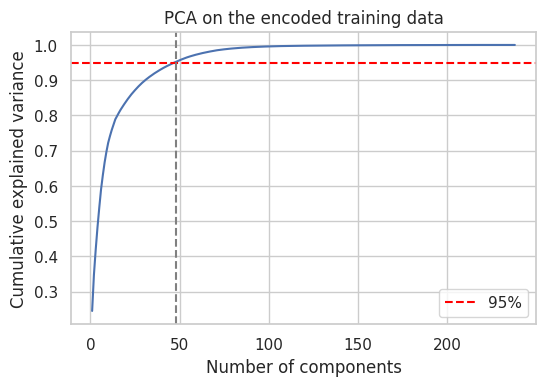

In [16]:
# How many principal components are needed to keep 95% of the variance?
prep_only = ColumnTransformer([("scale", StandardScaler(), num_cols)], remainder="passthrough")
Xtr_scaled = prep_only.fit_transform(X_train)
pca_full = PCA().fit(Xtr_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"{X_train.shape[1]} features -> {n95} components keep 95% of the variance")

plt.figure(figsize=(6, 3.8))
plt.plot(range(1, len(cum_var) + 1), cum_var)
plt.axhline(0.95, color="red", ls="--", label="95%")
plt.axvline(n95, color="gray", ls="--")
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance")
plt.title("PCA on the encoded training data"); plt.legend()
plt.show()

## 4. Algorithm background and justification

### 4.1 What is Logistic Regression?
Logistic Regression is a **supervised, linear classification algorithm**. For a student with features **x**, it computes a score
for each class *k* as a linear combination of the features, z<sub>k</sub> = w<sub>k</sub>·x + b<sub>k</sub>. For more than two classes,
the **softmax** function turns the scores into probabilities that sum to 1:

P(class = k | x) = exp(z<sub>k</sub>) / Σ<sub>j</sub> exp(z<sub>j</sub>)

The student is assigned to the class with the highest probability (here: Dropout, Enrolled or Graduate).

### 4.2 How it learns
The weights are found by minimising the **cross-entropy (log-loss)** between predicted probabilities and true labels, plus a
**regularisation penalty** on the weights. The strength of the penalty is controlled by **C** (the *inverse* of regularisation
strength: small C = strong regularisation). **L2** shrinks all weights; **L1** drives some weights to exactly zero (feature selection).
The optimisation is convex, so it finds a global optimum. This project uses the `lbfgs` solver.

### 4.3 Why it suits this dataset
- The problem is **multi-class classification** with a labelled target, and Logistic Regression supports it directly (multinomial).
- It gives **probabilities**, useful for ranking students by dropout risk.
- It is **interpretable**: coefficients show which factors push a student toward dropout or graduation, which is valuable for an institution planning interventions.
- It is a strong, fast **baseline**, and regularisation handles the **many correlated and one-hot features** (238 columns after encoding).
- With `class_weight="balanced"` it can handle the **class imbalance** ("Enrolled" is only ~18%).
- It contrasts clearly with my teammate's **Random Forest** (linear model vs. non-linear tree ensemble), which makes the comparison meaningful.

### 4.4 Assumptions and limitations
Assumes a **linear** relationship between features and the log-odds of each class, and needs scaled, encoded inputs.
It cannot capture feature interactions or non-linear patterns unless they are engineered manually, so it may underperform ensemble models.

### 4.5 Hyperparameters tuned
| Hyperparameter | Meaning | Values tried |
|---|---|---|
| `C` | Inverse regularisation strength | 0.001, 0.01, 0.1, 1, 10, 100 |
| `class_weight` | Penalise mistakes on small classes more | `None`, `"balanced"` |

Scoring metric for tuning is **macro-F1**, because accuracy alone hides poor performance on the small "Enrolled" class.

## 5. Model implementation

### 5.1 Baseline model (default settings)

In [17]:
baseline = build_pipeline(num_cols)
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

base_acc = accuracy_score(y_test, pred_base)
base_f1 = f1_score(y_test, pred_base, average="macro")
print(f"Baseline  accuracy = {base_acc:.3f} | macro-F1 = {base_f1:.3f}")

Baseline  accuracy = 0.773 | macro-F1 = 0.696


### 5.2 Hyperparameter tuning (cross-validation on the training set only)

In [18]:
param_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "clf__class_weight": [None, "balanced"]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(build_pipeline(num_cols), param_grid, cv=cv,
                    scoring="f1_macro", n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

print("Best parameters      :", grid.best_params_)
print(f"Best CV macro-F1     : {grid.best_score_:.3f}")

cv_results = (pd.DataFrame(grid.cv_results_)
              [["param_clf__C", "param_clf__class_weight", "mean_train_score", "mean_test_score", "std_test_score"]]
              .sort_values("mean_test_score", ascending=False))
display(cv_results.round(3).head(8))

Best parameters      : {'clf__C': 0.1, 'clf__class_weight': 'balanced'}
Best CV macro-F1     : 0.715


,param_clf__C,param_clf__class_weight,mean_train_score,mean_test_score,std_test_score
5,0.10,balanced,0.749,0.715,0.015
7,1.00,balanced,0.765,0.710,0.014
9,10.00,balanced,0.772,0.704,0.015
11,100.00,balanced,0.772,0.701,0.017
6,1.00,None,0.750,0.697,0.015
8,10.00,None,0.762,0.694,0.012
3,0.01,balanced,0.713,0.693,0.015
10,100.00,None,0.765,0.692,0.014


**Reading the plot:** Cross-validated macro-F1 peaks at C = 0.1 with class_weight="balanced" (0.715). With very strong regularisation (C = 0.01) both the training score (0.713) and validation score (0.693) are lower, which indicates underfitting. As C increases beyond 0.1, the training score rises (to 0.772 at C = 100) while the validation score falls (to 0.701), so the train–validation gap widens from 0.034 to 0.071, a sign of mild overfitting. Using balanced class weights gave a higher validation score than no weighting at the same C (e.g. 0.710 vs. 0.697 at C = 1). However, the whole range of scores is narrow (about 0.69–0.715) and the fold-to-fold standard deviation is about 0.015, so the effect of C is modest and the model is not very sensitive to this hyperparameter.

## 6. Results on the held-out test set  


In [19]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)
classes = list(best_model.classes_)

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Test accuracy : {test_acc:.3f}")
print(f"Test macro-F1 : {test_f1:.3f}")
print()
print(classification_report(y_test, y_pred, digits=3))

Test accuracy : 0.734
Test macro-F1 : 0.696

              precision    recall  f1-score   support

     Dropout      0.824     0.690     0.751       284
    Enrolled      0.417     0.635     0.504       159
    Graduate      0.872     0.799     0.834       442

    accuracy                          0.734       885
   macro avg      0.704     0.708     0.696       885
weighted avg      0.775     0.734     0.748       885



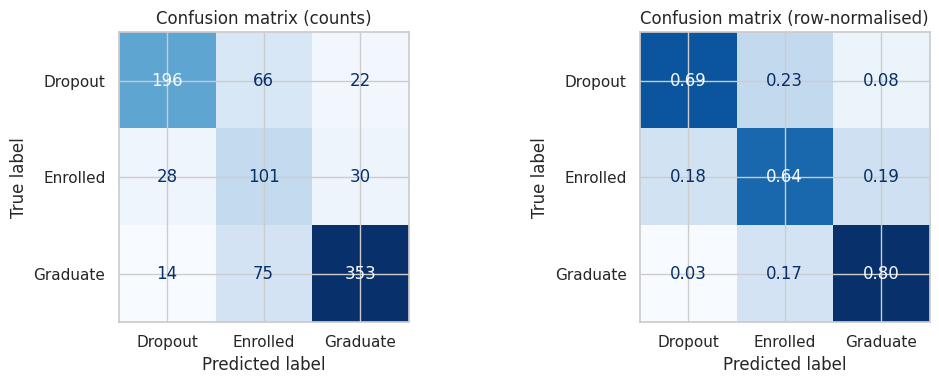

In [20]:
# Confusion matrices: raw counts and row-normalised (recall per class)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true", ax=axes[1],
                                        cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Confusion matrix (row-normalised)")
plt.tight_layout()
plt.show()

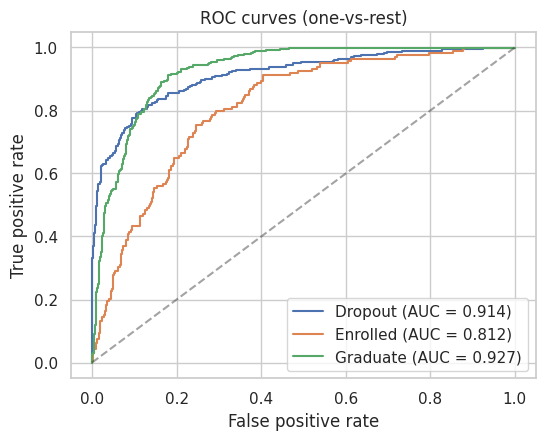

Macro-average AUC (OvR): 0.884


In [21]:
# One-vs-rest ROC curves and AUC
y_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(6, 4.5))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f"{c} (AUC = {roc_auc_score(y_bin[:, i], y_proba[:, i]):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves (one-vs-rest)"); plt.legend()
plt.show()

macro_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Macro-average AUC (OvR): {macro_auc:.3f}")

In [22]:
# Stability check: 5-fold CV of the final model on the TRAINING data
cv_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")
cv_f1 = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="f1_macro")
print(f"CV accuracy : {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"CV macro-F1 : {cv_f1.mean():.3f} +/- {cv_f1.std():.3f}")

CV accuracy : 0.756 +/- 0.013
CV macro-F1 : 0.715 +/- 0.015


In [23]:
# Summary table: baseline vs. tuned model
summary = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Logistic Regression (tuned)"],
    "Accuracy": [base_acc, test_acc],
    "Macro-F1": [base_f1, test_f1],
    "Macro-Precision": [precision_score(y_test, pred_base, average="macro"), precision_score(y_test, y_pred, average="macro")],
    "Macro-Recall": [recall_score(y_test, pred_base, average="macro"), recall_score(y_test, y_pred, average="macro")],
}).round(3)
summary

,Model,Accuracy,Macro-F1,Macro-Precision,Macro-Recall
0,Logistic Regression (baseline),0.773,0.696,0.719,0.687
1,Logistic Regression (tuned),0.734,0.696,0.704,0.708


### 6.1 Model interpretation

Features that most REDUCE the odds of Dropout:


,Dropout
Tuition fees up to date,-1.388
Curricular units 2nd sem (approved),-1.303
Curricular units 1st sem (approved),-0.665
Mother's occupation_191,-0.515
Course_171,-0.439
Course_9238,-0.292
Curricular units 2nd sem (grade),-0.292
International,-0.252


Features that most INCREASE the odds of Dropout:


,Dropout
Debtor,0.297
Application mode_7,0.317
Father's occupation_90,0.385
Father's qualification_34,0.446
Course_9130,0.519
Course_9853,0.589
Mother's qualification_34,0.595
Curricular units 2nd sem (enrolled),0.627


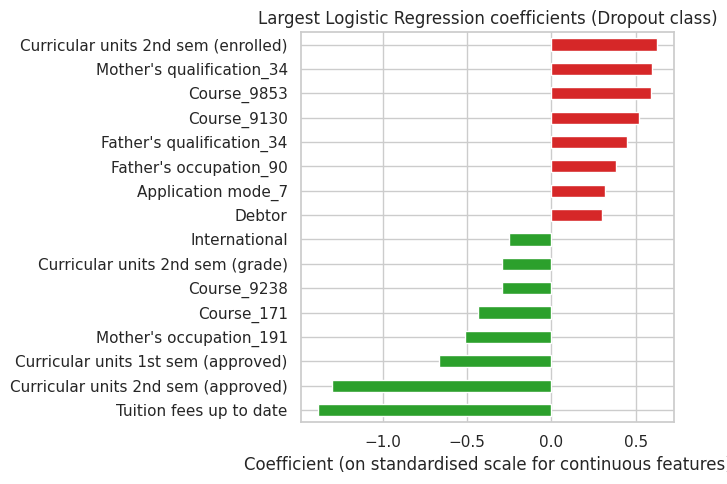

In [24]:
feature_names = [n.split("__", 1)[1] for n in best_model.named_steps["prep"].get_feature_names_out()]
coefs = pd.DataFrame(best_model.named_steps["clf"].coef_.T, index=feature_names, columns=classes)

top = coefs["Dropout"].sort_values()
print("Features that most REDUCE the odds of Dropout:")
display(top.head(8).round(3))
print("Features that most INCREASE the odds of Dropout:")
display(top.tail(8).round(3))

plt.figure(figsize=(7, 5))
pd.concat([top.head(8), top.tail(8)]).plot(kind="barh", color=["tab:green"] * 8 + ["tab:red"] * 8)
plt.title("Largest Logistic Regression coefficients (Dropout class)")
plt.xlabel("Coefficient (on standardised scale for continuous features)")
plt.tight_layout()
plt.show()

In [25]:
# Save results so they can be compared with the teammate's Random Forest results
os.makedirs("results", exist_ok=True)
results = {
    "model": "Logistic Regression",
    "best_params": {k.replace("clf__", ""): (None if v is None else (float(v) if isinstance(v, (int, float, np.floating)) else v))
                    for k, v in grid.best_params_.items()},
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1), 4),
    "test_macro_auc_ovr": round(float(macro_auc), 4),
    "cv_macro_f1_mean": round(float(cv_f1.mean()), 4),
    "per_class": classification_report(y_test, y_pred, output_dict=True, digits=4),
}
with open("results/logistic_regression_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved results/logistic_regression_results.json")

Saved results/logistic_regression_results.json
